In [1]:
import pandas as pd
import numpy as np
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = kagglehub.dataset_download("ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training")
csv_path = os.path.join(path, "dirty_cafe_sales.csv")
sales = pd.read_csv(csv_path)
sales.shape

100%|██████████| 111k/111k [00:00<00:00, 534kB/s]

Extracting files...


(10000, 8)

In [3]:
sales.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [5]:
sales = sales.replace(
    ["ERROR", "UNKNOWN", "unknown", "error", "", " ", "None", "null", "NULL"],
    np.nan
)

sales["Transaction Date"] = pd.to_datetime(
    sales["Transaction Date"], errors="coerce"
)

for col in ["Quantity", "Price Per Unit", "Total Spent"]:
    sales[col] = pd.to_numeric(sales[col], errors="coerce")

In [6]:
sales["Total Spent"] = sales["Total Spent"].where(
    sales["Total Spent"].notna(),
    sales["Quantity"] * sales["Price Per Unit"]
)

In [7]:
sales["Day"] = sales["Transaction Date"].dt.day_name()
sales["Day Type"] = np.where(
    sales["Transaction Date"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday"
)

In [8]:
valid_transaction = (
    sales["Transaction Date"].notna()
    & sales["Item"].notna()
    & sales["Quantity"].notna()
    & (sales["Quantity"] > 0)
    & sales["Price Per Unit"].notna()
    & (sales["Price Per Unit"] > 0)
    & sales["Total Spent"].notna()
    & (sales["Total Spent"] > 0)
    & sales["Payment Method"].notna()
    & sales["Location"].notna()
)

clean_sales = sales[valid_transaction].copy()
clean_sales.shape

(3234, 10)

In [9]:
clean_sales.isna().sum()

,0
Transaction ID,0
Item,0
Quantity,0
Price Per Unit,0
Total Spent,0
Payment Method,0
Location,0
Transaction Date,0
Day,0
Day Type,0


In [10]:
revenue_by_product = clean_sales.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)
revenue_by_product

,Total Spent
Item,
Salad,6650.0
Sandwich,5040.0
Smoothie,4360.0
Juice,3885.0
Cake,3669.0
Coffee,2334.0
Tea,1794.0
Cookie,1229.0


In [11]:
revenue_by_location = clean_sales.groupby("Location")["Total Spent"].sum().sort_values(ascending=False)
revenue_by_location

,Total Spent
Location,
In-store,14807.5
Takeaway,14153.5


In [12]:
revenue_by_payment = clean_sales.groupby("Payment Method")["Total Spent"].sum().sort_values(ascending=False)
revenue_by_payment

,Total Spent
Payment Method,
Digital Wallet,10160.0
Cash,9564.5
Credit Card,9236.5


In [13]:
weekend_vs_weekday = clean_sales.groupby("Day Type")["Total Spent"].sum().sort_values(ascending=False)
weekend_vs_weekday

,Total Spent
Day Type,
Weekday,20589.0
Weekend,8372.0


In [14]:
sales_by_day = clean_sales.groupby("Day")["Total Spent"].sum().sort_values(ascending=False)
peak_sales_day = sales_by_day.idxmax()
peak_sales_revenue = sales_by_day.max()
peak_sales_day, peak_sales_revenue

('Monday', 4377.0)

In [15]:
quantity_by_product = clean_sales.groupby("Item")["Quantity"].sum().sort_values(ascending=False)
best_selling_item = quantity_by_product.idxmax()
best_selling_quantity = quantity_by_product.max()
best_selling_item, best_selling_quantity

('Salad', 1330.0)

In [16]:
product_revenue = clean_sales.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)
product_revenue_contribution = (product_revenue / product_revenue.sum() * 100).round(2)
product_revenue_contribution

,Total Spent
Item,
Salad,22.96
Sandwich,17.40
Smoothie,15.05
Juice,13.41
Cake,12.67
Coffee,8.06
Tea,6.19
Cookie,4.24


In [17]:
total_rows = len(sales)
successful_transactions = valid_transaction.sum()
transaction_success_rate = successful_transactions / total_rows * 100
transaction_success_rate

np.float64(32.34)

In [18]:
missing_data_rate = sales.isna().sum().sum() / (sales.shape[0] * sales.shape[1]) * 100
missing_data_rate

np.float64(10.08)

In [19]:
invalid_date_percentage = sales["Transaction Date"].isna().sum() / total_rows * 100
invalid_date_percentage

np.float64(4.6)

In [20]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Revenue by Product",
        "Revenue by Location",
        "Revenue by Payment Method",
        "Weekend vs Weekday Sales",
        "Peak Sales Day",
        "Best Selling Item",
        "Product Revenue Contribution (%)",
        "Transaction Success Rate",
        "Missing Data Rate",
        "Invalid Date Percentage"
    ],
    "Value": [
        revenue_by_product.to_dict(),
        revenue_by_location.to_dict(),
        revenue_by_payment.to_dict(),
        weekend_vs_weekday.to_dict(),
        f"{peak_sales_day} (${peak_sales_revenue:,.2f})",
        f"{best_selling_item} ({best_selling_quantity} units)",
        product_revenue_contribution.to_dict(),
        f"{transaction_success_rate:.2f}%",
        f"{missing_data_rate:.2f}%",
        f"{invalid_date_percentage:.2f}%"
    ]
})
kpi_summary

,KPI,Value
0,Revenue by Product,"{'Salad': 6650.0, 'Sandwich': 5040.0, 'Smoothi..."
1,Revenue by Location,"{'In-store': 14807.5, 'Takeaway': 14153.5}"
2,Revenue by Payment Method,"{'Digital Wallet': 10160.0, 'Cash': 9564.5, 'C..."
3,Weekend vs Weekday Sales,"{'Weekday': 20589.0, 'Weekend': 8372.0}"
4,Peak Sales Day,"Monday ($4,377.00)"
5,Best Selling Item,Salad (1330.0 units)
6,Product Revenue Contribution (%),"{'Salad': 22.96, 'Sandwich': 17.4, 'Smoothie':..."
7,Transaction Success Rate,32.34%
8,Missing Data Rate,10.08%
9,Invalid Date Percentage,4.60%


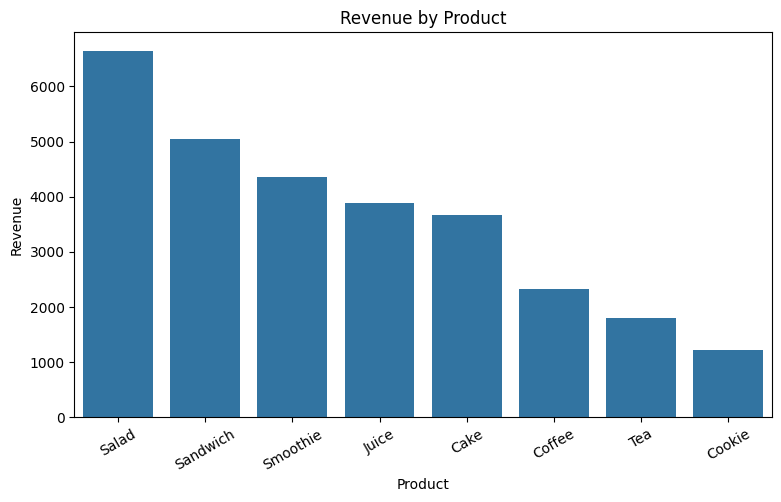

In [21]:
plt.figure(figsize=(9, 5))
sns.barplot(x=revenue_by_product.index, y=revenue_by_product.values)
plt.xticks(rotation=30)
plt.ylabel("Revenue")
plt.xlabel("Product")
plt.title("Revenue by Product")
plt.show()

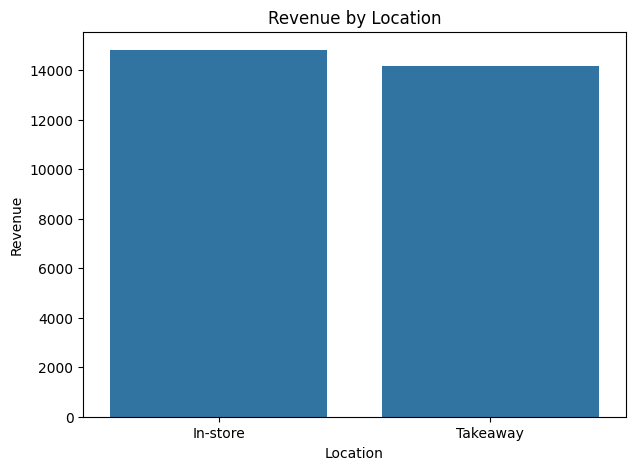

In [22]:
plt.figure(figsize=(7, 5))
sns.barplot(x=revenue_by_location.index, y=revenue_by_location.values)
plt.ylabel("Revenue")
plt.xlabel("Location")
plt.title("Revenue by Location")
plt.show()

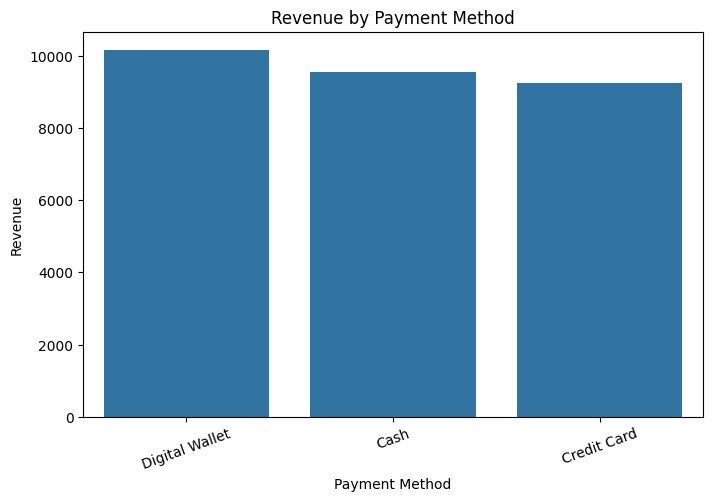

In [23]:
plt.figure(figsize=(8, 5))
sns.barplot(x=revenue_by_payment.index, y=revenue_by_payment.values)
plt.xticks(rotation=20)
plt.ylabel("Revenue")
plt.xlabel("Payment Method")
plt.title("Revenue by Payment Method")
plt.show()

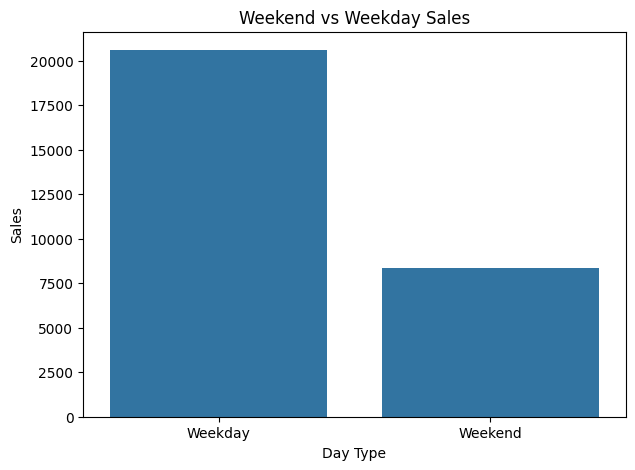

In [24]:
plt.figure(figsize=(7, 5))
sns.barplot(x=weekend_vs_weekday.index, y=weekend_vs_weekday.values)
plt.ylabel("Sales")
plt.xlabel("Day Type")
plt.title("Weekend vs Weekday Sales")
plt.show()

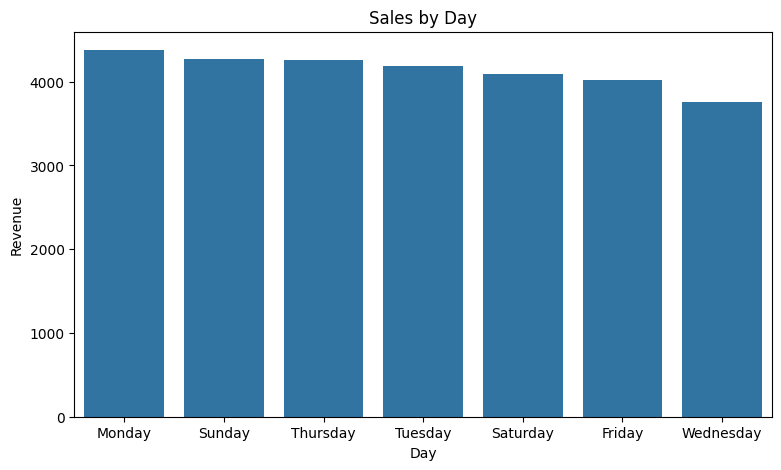

In [25]:
plt.figure(figsize=(9, 5))
sns.barplot(x=sales_by_day.index, y=sales_by_day.values)
plt.ylabel("Revenue")
plt.xlabel("Day")
plt.title("Sales by Day")
plt.show()

In [28]:
print("5. Peak Sales Day")
print("Day:", peak_sales_day)
print("Revenue:", peak_sales_revenue)

5. Peak Sales Day
Day: Monday
Revenue: 4377.0


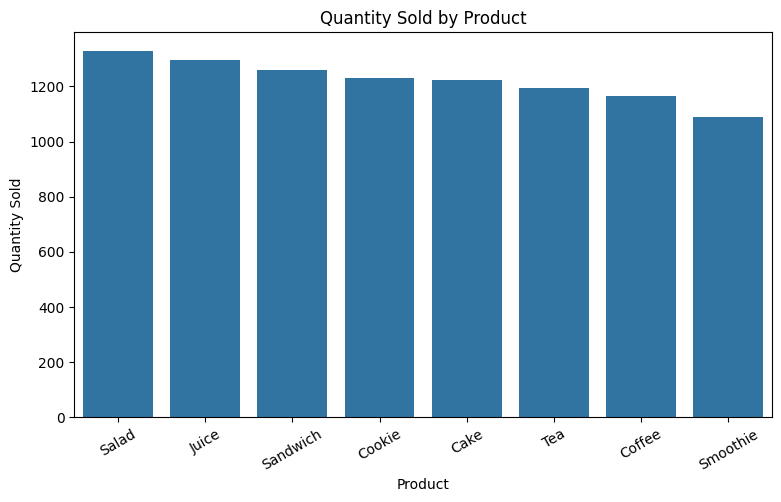

In [26]:
plt.figure(figsize=(9, 5))
sns.barplot(x=quantity_by_product.index, y=quantity_by_product.values)
plt.xticks(rotation=30)
plt.ylabel("Quantity Sold")
plt.xlabel("Product")
plt.title("Quantity Sold by Product")
plt.show()

In [29]:
print("6. Best Selling Item")
print("Item:", best_selling_item)
print("Quantity Sold:", best_selling_quantity)

6. Best Selling Item
Item: Salad
Quantity Sold: 1330.0


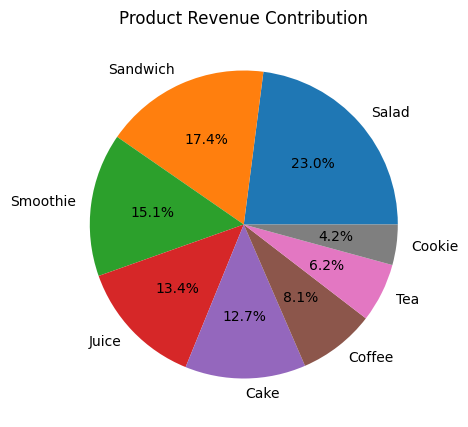

In [27]:
plt.figure(figsize=(9, 5))
plt.pie(product_revenue_contribution.values, labels=product_revenue_contribution.index, autopct="%1.1f%%")
plt.title("Product Revenue Contribution")
plt.show()

In [30]:
print("8. Transaction Success Rate")
print(f"{transaction_success_rate:.2f}%")

8. Transaction Success Rate
32.34%


In [31]:
print("9. Missing Data Rate")
print(f"{missing_data_rate:.2f}%")

9. Missing Data Rate
10.08%


In [32]:
print("10. Invalid Date Percentage")
print(f"{invalid_date_percentage:.2f}%")

10. Invalid Date Percentage
4.60%
